In [4]:
import numpy as np
import rasterio
from rasterio.windows import Window
from rasterio.mask import mask
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from typing import Tuple, List, Dict
from tqdm import tqdm
import os
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.ndimage import zoom
import numpy as np
import numpy as np
import random
import json
from pathlib import Path
from typing import Dict, List, Tuple
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from typing import Dict, Tuple
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
from pathlib import Path

from data_loader import (
    load_dem, load_infiltration_map, load_landuse_map, print_raster_stats,gmm_no_manila_path_box_load_all_flood_maps,
    load_all_rainfall_scenarios, get_rainfall_stats, visualize_raster, visualize_flood_maps_grid, manila_path_shape_load_all_flood_maps,
    get_raster_stats, load_manila_mask, gmm_path_load_all_flood_maps
)

from data_preprocessing import (normalize_dem, normalize_infiltration, normalize_landuse, handle_nodata )

from flood_maps import (FLOOD_CLASSES, reconstruct_map_from_patches, categorize_all_flood_maps_patch, visualize_all_categorized_maps)

from quadrant import ( stack_spatial_inputs, split_into_quadrants, build_train_test_split, extract_spatial_patches, get_quadrant_patch_indices, visualize_quadrant_split )

from vit import ViT

from training import FloodPatchDataset, train_kfold

RANDOM_SEED = 42
NUM_SCENARIO = 50
PATCH_SIZE = 4

In [5]:
repo_root = os.getcwd()
gmm_path = os.path.join(repo_root, "COP-30m-GMM")
gmm_no_manila_path = os.path.join(repo_root, "COP-30m-GMM-ManilaMaskOut")
manila_path = os.path.join(repo_root, "COP-30m-ManilaOnly")
rainfall_path = os.path.join(repo_root, "mm_hr_scenarios")

# Loading data


--- Loading DEM ---
DEM loaded: shape (1224, 1125), dtype float32

Statistics for: DEM
Shape:         (1224, 1125)
Dtype:         float32
Min value:     -9.1316
Max value:     466.3908
Mean value:    42.0699
Std dev:       69.0678
Valid pixels:  1,377,000 / 1,377,000


--- Loading Infiltration Map ---
Infiltration map loaded: shape (1224, 1125), dtype float64

Statistics for: Infiltration Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     0.0000
Max value:     3.6847
Mean value:    0.4818
Std dev:       0.9485
Valid pixels:  1,377,000 / 1,377,000


--- Loading Landuse Map ---
Landuse map loaded: shape (1224, 1125), dtype float64

Statistics for: Landuse Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     1.0000
Max value:     11.0000
Mean value:    4.9338
Std dev:       2.5013
Valid pixels:  1,377,000 / 1,377,000


--- Loading Flood Maps (Ground Truth) ---
Flood map RS1 loaded: shape (1224, 1125), dtype float64
Flood map RS2 loaded: shape (1224, 11

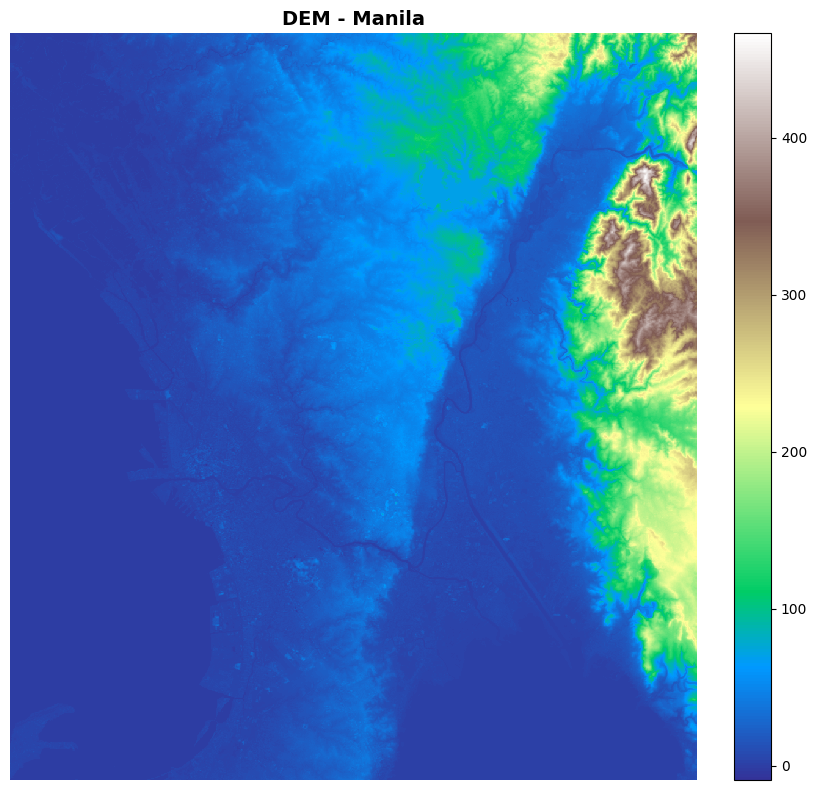

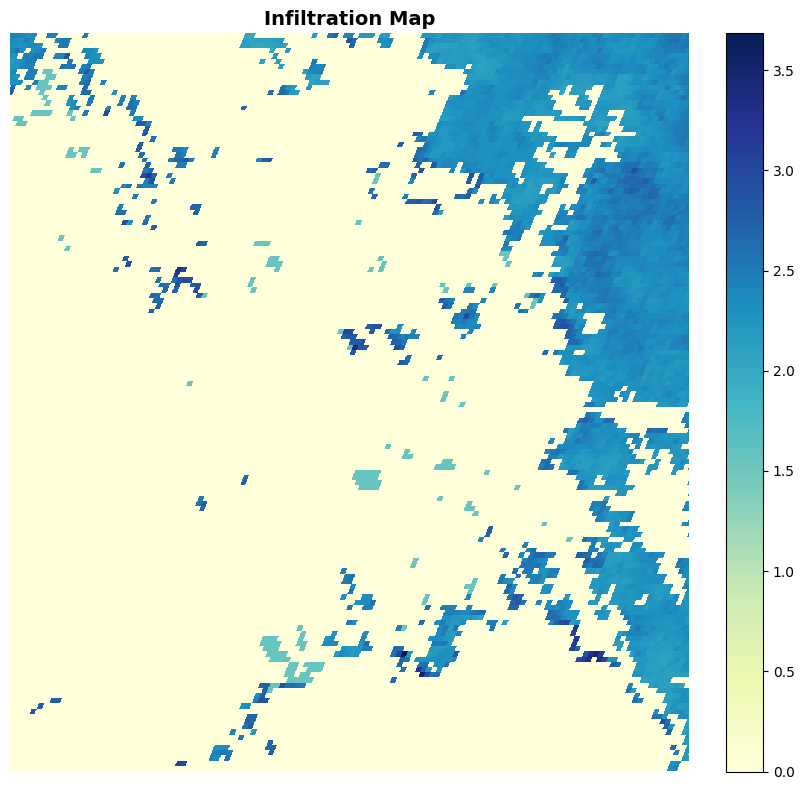

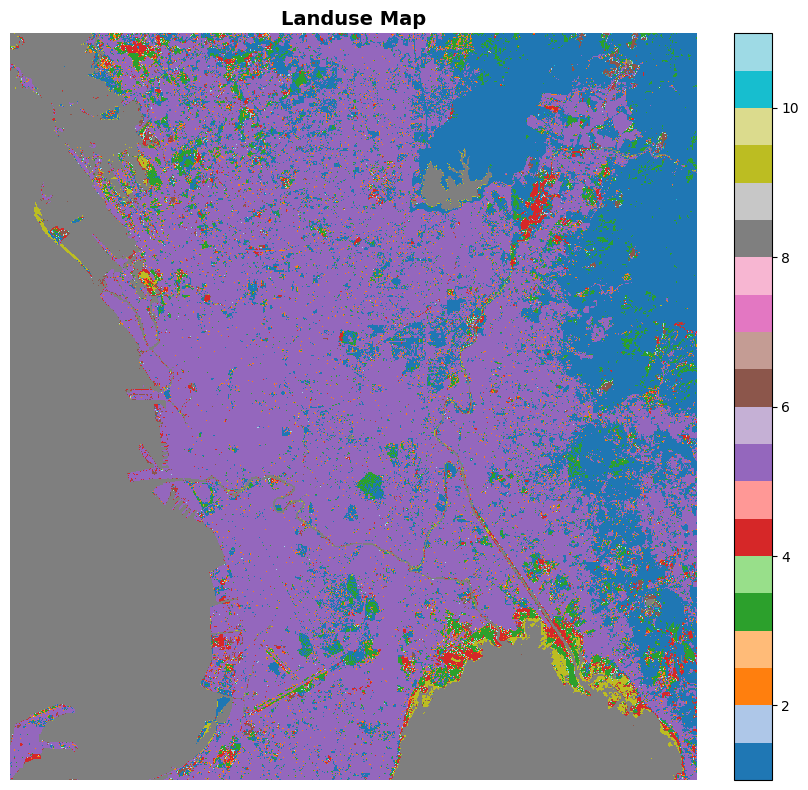

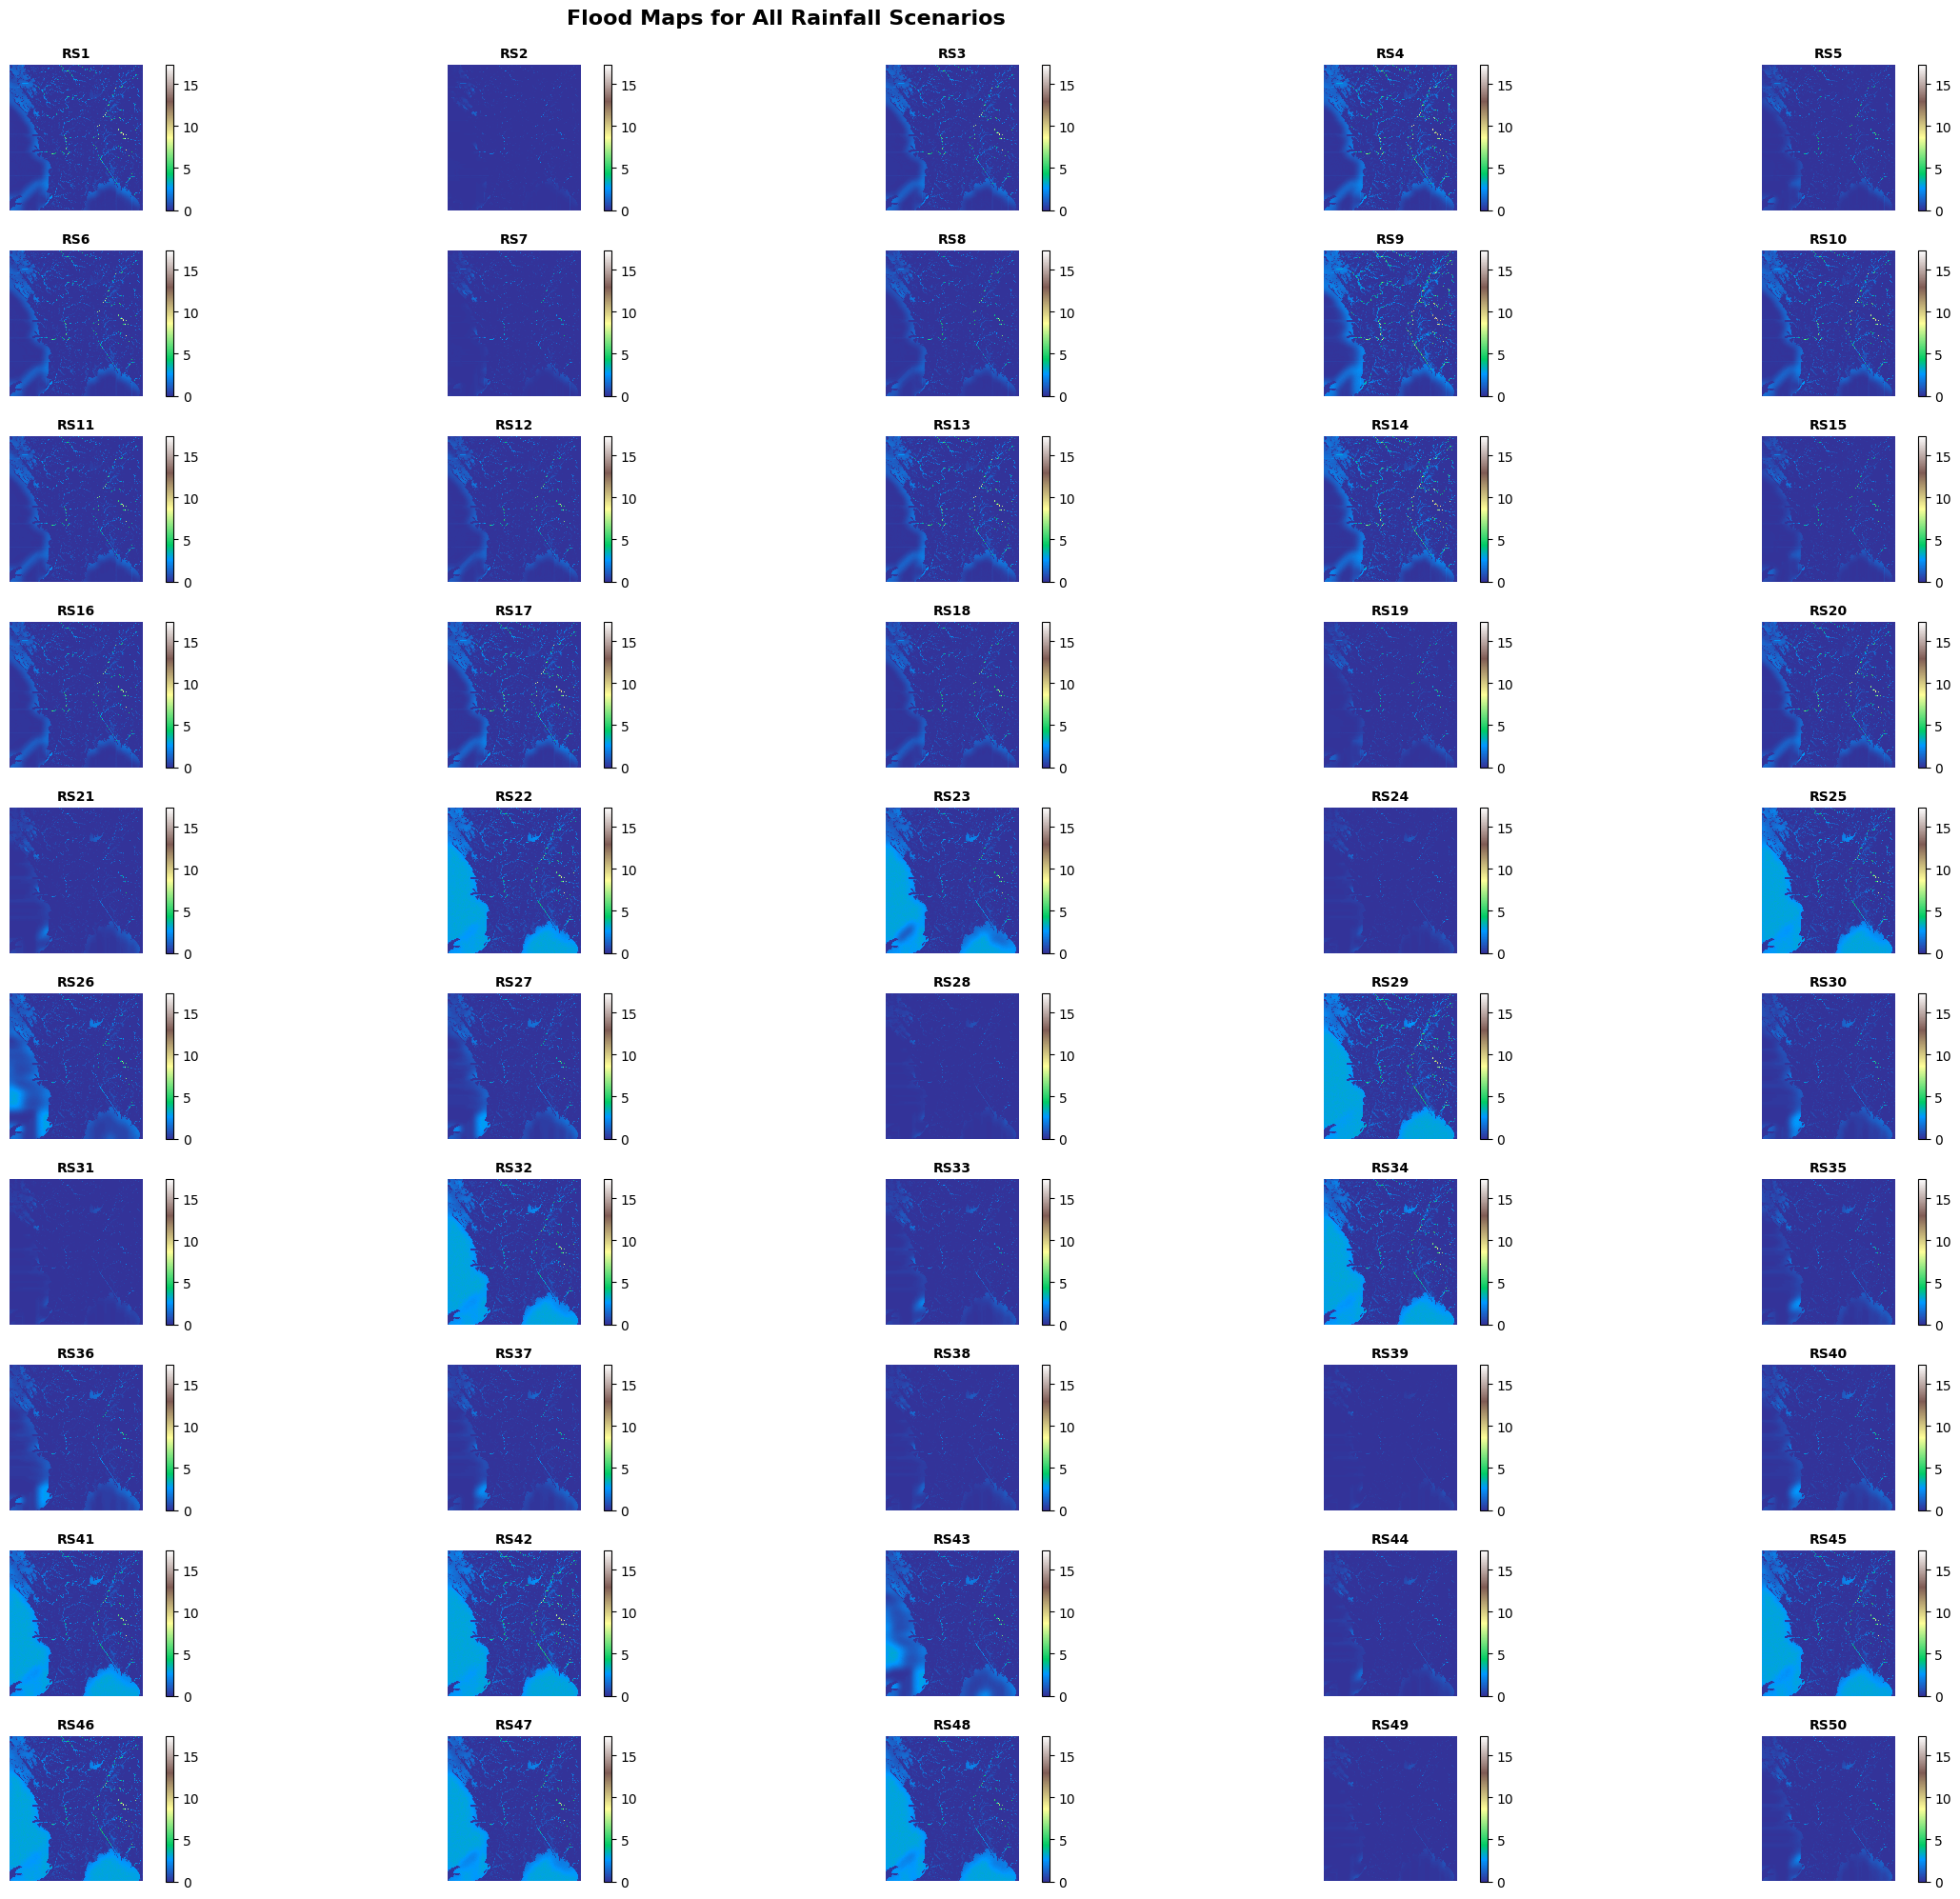

In [6]:
# Load DEM
print("\n--- Loading DEM ---")
dem_path = os.path.join(gmm_path, "greater_mm_bbox_dem_cop.tif")
if os.path.exists(dem_path):
    dem_data, dem_meta = load_dem(dem_path)
    dem_stats = get_raster_stats(dem_data, "DEM")
    print_raster_stats(dem_stats)
else:
    print(f"WARNING: DEM file not found at {dem_path}")
    dem_data = None

fig1 = visualize_raster(dem_data, title="DEM - Manila", cmap='terrain')

# Load Infiltration Map
print("\n--- Loading Infiltration Map ---")
infilt_path = os.path.join(gmm_path, "GM_Infilt_fixed.tif")
if os.path.exists(infilt_path):
    infilt_data, infilt_meta = load_infiltration_map(infilt_path)
    infilt_stats = get_raster_stats(infilt_data, "Infiltration Map")
    print_raster_stats(infilt_stats)
else:
    print(f"WARNING: Infiltration file not found at {infilt_path}")
    infilt_data = None
fig2 = visualize_raster(infilt_data, title="Infiltration Map", cmap='YlGnBu')

# Load Landuse Map
print("\n--- Loading Landuse Map ---")
landuse_path =  os.path.join(gmm_path, "GM_LU.tif")
if os.path.exists(landuse_path):
    landuse_data, landuse_meta = load_landuse_map(landuse_path)
    landuse_stats = get_raster_stats(landuse_data, "Landuse Map")
    print_raster_stats(landuse_stats)
else:
    print(f"WARNING: Landuse file not found at {landuse_path}")
    landuse_data = None
    
fig3 = visualize_raster(landuse_data, title="Landuse Map", cmap='tab20')

# Load all flood maps
print("\n--- Loading Flood Maps (Ground Truth) ---")
fm_path = os.path.join(gmm_path, "exp-des-4")
flood_maps, flood_metadata = gmm_path_load_all_flood_maps(gmm_path, num_scenarios=NUM_SCENARIO)

if len(flood_maps) > 0:
    print(f"\nFlood maps successfully loaded: {len(flood_maps)}")
    
    if len(flood_maps) >= NUM_SCENARIO:
        flood_stats = get_raster_stats(flood_maps[-1], "Flood Map RS20")
else:
    print("WARNING: No flood maps loaded!")

fig4 = visualize_flood_maps_grid(flood_maps=flood_maps,scenario_ids=list(range(1, 51)),figsize=(25, 20),ncols=5,cmap='terrain')
print_raster_stats(flood_stats)

In [7]:
print("LOADING RAINFALL SCENARIOS")
# Load rainfall scenarios
rainfall_scenarios = load_all_rainfall_scenarios(rainfall_path)

LOADING RAINFALL SCENARIOS
Rainfall Scenario 1 loaded: 13 time steps
Rainfall Scenario 2 loaded: 13 time steps
Rainfall Scenario 3 loaded: 13 time steps
Rainfall Scenario 4 loaded: 13 time steps
Rainfall Scenario 5 loaded: 13 time steps
Rainfall Scenario 6 loaded: 13 time steps
Rainfall Scenario 7 loaded: 13 time steps
Rainfall Scenario 8 loaded: 13 time steps
Rainfall Scenario 9 loaded: 13 time steps
Rainfall Scenario 10 loaded: 13 time steps
Rainfall Scenario 11 loaded: 13 time steps
Rainfall Scenario 12 loaded: 13 time steps
Rainfall Scenario 13 loaded: 13 time steps
Rainfall Scenario 14 loaded: 13 time steps
Rainfall Scenario 15 loaded: 13 time steps
Rainfall Scenario 16 loaded: 13 time steps
Rainfall Scenario 17 loaded: 13 time steps
Rainfall Scenario 18 loaded: 13 time steps
Rainfall Scenario 19 loaded: 13 time steps
Rainfall Scenario 20 loaded: 13 time steps
Rainfall Scenario 21 loaded: 13 time steps
Rainfall Scenario 22 loaded: 13 time steps
Rainfall Scenario 23 loaded: 13 time

# Data Preprocessing

In [8]:
print("\nProcessing DEM...")
dem_clean = handle_nodata(dem_data, nodata_value=dem_meta.get('nodata'), fill_method='mean')

print("\nProcessing Infiltration...")
infilt_clean = handle_nodata(infilt_data, nodata_value=infilt_meta.get('nodata'), fill_method='mean')

print("\nProcessing Landuse...")
landuse_clean = handle_nodata(landuse_data, nodata_value=landuse_meta.get('nodata'), fill_method='interpolate')


Processing DEM...

Handling NoData for Raster...
  NoData pixels: 0 / 1,377,000 (0.00%)
  ✓ No NoData values found

Processing Infiltration...

Handling NoData for Raster...
  NoData pixels: 0 / 1,377,000 (0.00%)
  ✓ No NoData values found

Processing Landuse...

Handling NoData for Raster...
  NoData pixels: 0 / 1,377,000 (0.00%)
  ✓ No NoData values found


In [9]:
# Normalize DEM
print("\nNormalizing DEM...")
dem_normalized, dem_params = normalize_dem(dem_data, method='minmax')
# Verify normalization
dem_norm_stats = get_raster_stats(dem_normalized, "DEM (Normalized)")
print_raster_stats(dem_norm_stats)

# Normalize Infiltration
print("\nNormalizing Infiltration...")
infilt_normalized, infilt_params = normalize_infiltration(infilt_data)
# Verify normalization
infilt_norm_stats = get_raster_stats(infilt_normalized, "Infiltration (Normalized)")
print_raster_stats(infilt_norm_stats)

# Normalize Landuse
print("\nNormalizing Landuse...")
landuse_normalized, landuse_params = normalize_landuse(landuse_data, method='minmax')
# Verify normalization
landuse_norm_stats = get_raster_stats(landuse_normalized, "Landuse (Normalized)")
print_raster_stats(landuse_norm_stats)



Normalizing DEM...
DEM normalized (min-max): [-9.1316, 466.3908] -> [0.0, 1.0]

Statistics for: DEM (Normalized)
Shape:         (1224, 1125)
Dtype:         float32
Min value:     0.0000
Max value:     1.0000
Mean value:    0.1077
Std dev:       0.1452
Valid pixels:  1,377,000 / 1,377,000


Normalizing Infiltration...
Infiltration normalized (min-max): [0.0000, 3.6847] -> [0.0, 1.0]

Statistics for: Infiltration (Normalized)
Shape:         (1224, 1125)
Dtype:         float64
Min value:     0.0000
Max value:     1.0000
Mean value:    0.1308
Std dev:       0.2574
Valid pixels:  1,377,000 / 1,377,000


Normalizing Landuse...
Landuse normalized (min-max): [1.0000, 11.0000] -> [0.0, 1.0]

Statistics for: Landuse (Normalized)
Shape:         (1224, 1125)
Dtype:         float64
Min value:     0.0000
Max value:     1.0000
Mean value:    0.3934
Std dev:       0.2501
Valid pixels:  1,377,000 / 1,377,000



# Flood Maps (Ground Truths)

In [10]:
flood_maps_categorized_patch, patch_metadata = categorize_all_flood_maps_patch(flood_maps, patch_size=PATCH_SIZE, stride=None, categorization_method='majority', verbose=True)


PATCH-BASED FLOOD MAP CATEGORIZATION

Configuration:
  Patch size: 4×4
  Stride: 4 (non-overlapping)
  Categorization method: majority

Class definitions:
  Class 0: No Flood     [0.00, 0.15) m
  Class 1: Light        [0.15, 0.24) m
  Class 2: Moderate     [0.24, 0.46) m
  Class 3: Heavy        [0.46, 0.68) m
  Class 4: Extreme      [0.68, ∞) m

Scenario  1 (85986 patches):
  No Flood    : 64,152 patches (74.61%)
  Light       :  1,892 patches ( 2.20%)
  Moderate    :  3,905 patches ( 4.54%)
  Heavy       :  2,618 patches ( 3.04%)
  Extreme     : 13,419 patches (15.61%)
Scenario  2 (85986 patches):
  No Flood    : 82,402 patches (95.83%)
  Light       :  1,322 patches ( 1.54%)
  Moderate    :  1,553 patches ( 1.81%)
  Heavy       :    364 patches ( 0.42%)
  Extreme     :    345 patches ( 0.40%)
Scenario  3 (85986 patches):
  No Flood    : 64,911 patches (75.49%)
  Light       :  1,993 patches ( 2.32%)
  Moderate    :  3,906 patches ( 4.54%)
  Heavy       :  2,737 patches ( 3.18%)
  Ex

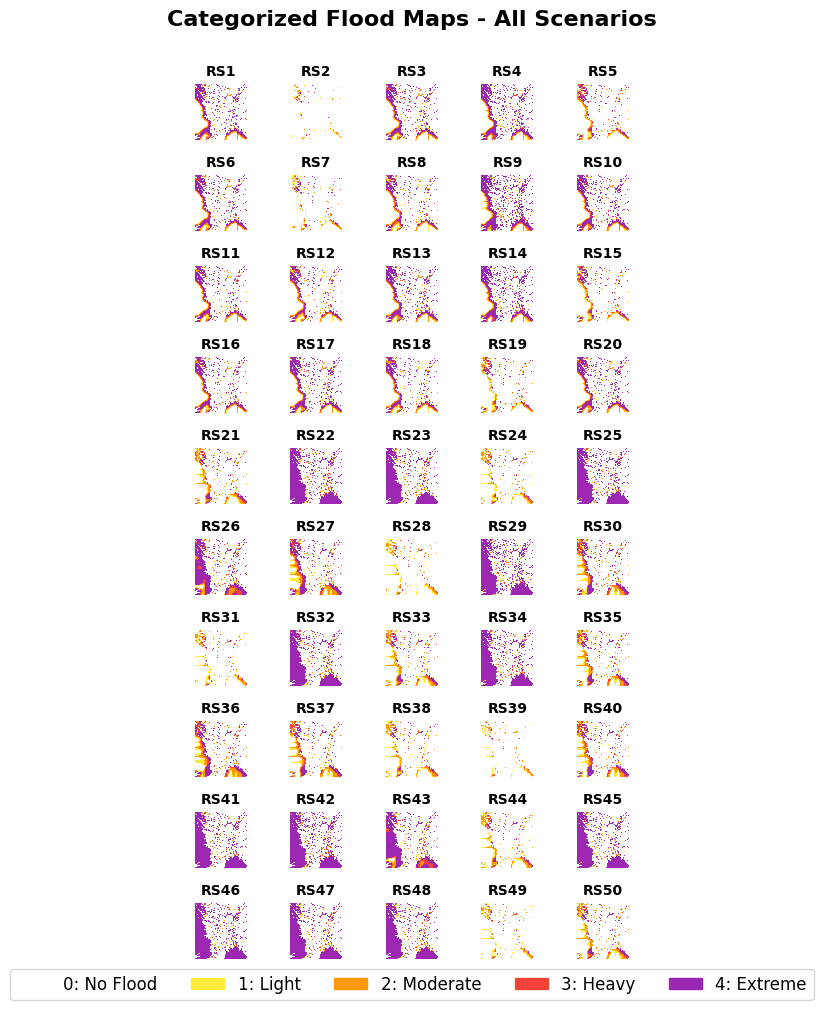

In [11]:
reconstructed_maps = []
for patch_labels, metadata in zip(flood_maps_categorized_patch, patch_metadata):
    reconstructed = reconstruct_map_from_patches(patch_labels, metadata, method='nearest')
    reconstructed_maps.append(reconstructed)
fig_all = visualize_all_categorized_maps(reconstructed_maps, scenario_ids=list(range(1, 51)), figsize=(5, 10), ncols=5)
plt.show()

In [12]:
display(flood_maps_categorized_patch)

[array([4, 4, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([0, 0, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([0, 0, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([0, 0, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([2, 2, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([3, 3, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([2, 2, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([0, 0, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([3, 3, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([4, 4, 0, ..., 0,

# Rainfall

In [13]:
import numpy as np
import pandas as pd
from typing import Dict, Any, List

# ── Storm Type Registry ───────────────────────────────────────────────────────
NUM_STORM_TYPES = 4
STORM_TYPE_MAP = {
    1: "SCS Front-loaded",
    2: "SCS Balanced",
    3: "SCS Back-loaded",
    4: "Triangular",
}

def _infer_type_id_from_sid(sid: int) -> int:
    """Infer storm type directly from scenario ID (fixed dataset design)."""
    if   1  <= sid <= 10: return 1
    elif 11 <= sid <= 20: return 2
    elif 21 <= sid <= 30: return 3
    elif 31 <= sid <= 50: return 4
    else:
        raise ValueError(f"Scenario ID {sid} out of expected range 1–50")

# ── Loader ────────────────────────────────────────────────────────────────────
def load_scenario_metadata(info_csv_path: str) -> Dict[int, Dict[str, Any]]:
    df = pd.read_csv(info_csv_path)

    required = {
        "No",
        "Pattern Type",
        "Total storm depth P (mm)",
        "Peak time fraction r (tpeak / D)",
    }

    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"info.csv missing columns: {missing}")

    metadata = {}

    for _, row in df.iterrows():
        sid = int(row["No"])
        type_id = _infer_type_id_from_sid(sid)

        # r = 0.0 for SCS types; actual value for triangular
        if type_id in (1, 2, 3):
            r = 0.0
        else:
            r = float(row["Peak time fraction r (tpeak / D)"])

        metadata[sid] = {
            "type_id": type_id,
            "label": STORM_TYPE_MAP[type_id],
            "pattern_type": row["Pattern Type"],
            "total_depth_mm": float(row["Total storm depth P (mm)"]),
            "r": r,
        }

    print(f"Loaded {len(metadata)} scenarios from {info_csv_path}")
    return metadata

# ── One-Hot Encoding ──────────────────────────────────────────────────────────
def get_storm_type_onehot(sid: int, scenario_metadata: Dict[int, Dict[str, Any]]) -> np.ndarray:
    """Return (4,) one-hot vector for storm type."""
    type_id = scenario_metadata[sid]["type_id"]
    onehot = np.zeros(NUM_STORM_TYPES, dtype=np.float32)
    onehot[type_id - 1] = 1.0
    return onehot

def build_all_storm_onehots(scenario_metadata: Dict[int, Dict[str, Any]]) -> np.ndarray:
    """Return (N_scenarios, 4) one-hot matrix."""
    sids = sorted(scenario_metadata.keys())
    onehots = np.stack(
        [get_storm_type_onehot(sid, scenario_metadata) for sid in sids],
        axis=0
    )

    print(f"Storm one-hot matrix shape: {onehots.shape}")
    return onehots

# ── Conditioning Vector ───────────────────────────────────────────────────────
# rain(13) + onehot(4) + r(1) + depth_norm(1) = 19 dims
CONDITIONING_DIM = 19

def build_conditioning_vector(
    rain_normalized: np.ndarray,  # (13,)
    type_id: int,                 # 1
    r: float,                     # 0.0
    total_depth_mm: float,        # 38.0
    depth_min: float,             # 5.0
    depth_max: float,             # 78.0
) -> np.ndarray:
    """Build full (19,) conditioning vector."""

    # Step 1: Create one-hot for storm type
    onehot = np.zeros(4, dtype=np.float32)
    onehot[type_id - 1] = 1.0  # type_id=1 → onehot[0]=1.0
    # Result: [1.0, 0.0, 0.0, 0.0]

    # Step 2: Normalize depth to [0, 1]
    depth_norm = (total_depth_mm - depth_min) / (depth_max - depth_min)

    # Step 3: Concatenate all 19 dimensions
    return np.concatenate([
        rain_normalized.astype(np.float32),   # (13,) rainfall
        onehot,                               # (4,) storm type one-hot
        [np.float32(r)],                      # (1,) r parameter → [0.0]
        [np.float32(depth_norm)],             # (1,) normalized depth → [0.452]
    ])
    # Result: (19,) vector


def build_all_conditioning_vectors(
    rain_embeddings: np.ndarray,  # (50, 13) — normalized rainfall sequences
    scenario_metadata: Dict[int, Dict[str, Any]],  # 50 scenarios' metadata
    depth_min: float,             # Min depth from training (5.0 mm)
    depth_max: float,             # Max depth from training (78.0 mm)
) -> np.ndarray:                  # Returns (50, 19) — full conditioning vectors
    """Build (N_scenarios, 19) conditioning matrix."""

    sids = sorted(scenario_metadata.keys())  # [1, 2, 3, ..., 50]
    vectors = []

    for i, sid in enumerate(sids):
        m = scenario_metadata[sid]  # Get metadata for this scenario

        vec = build_conditioning_vector(
            rain_normalized=rain_embeddings[i],      # (13,) rainfall for scenario i
            type_id=m["type_id"],                    # 1, 2, 3, or 4 (storm type)
            r=m["r"],                                # 0.0 for SCS, tpeak for triangular
            total_depth_mm=m["total_depth_mm"],      # Actual depth (mm)
            depth_min=depth_min,                     # 5.0
            depth_max=depth_max,                     # 78.0
        )

        vectors.append(vec)

    out = np.stack(vectors, axis=0)  # Stack all 50 vectors → (50, 19)

    print(f"Conditioning matrix shape: {out.shape}")
    return out


# ── Validation ────────────────────────────────────────────────────────────────
def validate_and_print_metadata(
    scenario_metadata: Dict[int, Dict[str, Any]],
    train_ids: List[int],
    test_ids: List[int],
) -> None:

    print("\n" + "=" * 70)
    print("SCENARIO METADATA SUMMARY")
    print("=" * 70)

    all_ids = sorted(scenario_metadata.keys())
    print(f"\nTotal scenarios: {len(all_ids)}")

    # Full dataset distribution
    print("\nStorm type distribution (full dataset):")

    for tid, label in STORM_TYPE_MAP.items():
        ids = [sid for sid, m in scenario_metadata.items()
               if m["type_id"] == tid]

        if not ids:
            continue

        depths = [scenario_metadata[sid]["total_depth_mm"] for sid in ids]

        print(f"  Type {tid} - {label:<18}: "
              f"{len(ids):>2} scenarios  "
              f"(IDs {min(ids)}–{max(ids)})  "
              f"depth {min(depths):.0f}–{max(depths):.0f} mm")

    # Train distribution
    print("\nTrain set distribution:")
    for tid, label in STORM_TYPE_MAP.items():
        ids = [sid for sid in train_ids
               if scenario_metadata[sid]["type_id"] == tid]
        print(f"  Type {tid} - {label:<18}: {len(ids)}")

    # Test distribution
    print("\nTest set distribution:")
    for tid, label in STORM_TYPE_MAP.items():
        ids = [sid for sid in test_ids
               if scenario_metadata[sid]["type_id"] == tid]
        print(f"  Type {tid} - {label:<18}: {len(ids)}")

    # Triangular r range
    triangular = [
        m["r"] for m in scenario_metadata.values()
        if m["type_id"] == 4
    ]

    if triangular:
        print(f"\nTriangular r range: "
              f"{min(triangular):.2f} – {max(triangular):.2f}")

    print("=" * 70)

In [14]:
scenario_metadata = load_scenario_metadata(os.path.join(repo_root, "info.csv"))
validate_and_print_metadata(scenario_metadata, 
                             list(range(1, NUM_SCENARIO+1)),
                             list(range(1, NUM_SCENARIO+1)))

# ── Depth normalization stats (from training data) ────────────────────────────
all_depths = [m['total_depth_mm'] for m in scenario_metadata.values()]
depth_min, depth_max = min(all_depths), max(all_depths)
print(f"Depth range: {depth_min:.1f} – {depth_max:.1f} mm")


Loaded 50 scenarios from c:\Users\mikos\Documents\thesis\th3-experiments\info.csv

SCENARIO METADATA SUMMARY

Total scenarios: 50

Storm type distribution (full dataset):
  Type 1 - SCS Front-loaded  : 10 scenarios  (IDs 1–10)  depth 6–78 mm
  Type 2 - SCS Balanced      : 10 scenarios  (IDs 11–20)  depth 19–78 mm
  Type 3 - SCS Back-loaded   : 10 scenarios  (IDs 21–30)  depth 7–75 mm
  Type 4 - Triangular        : 20 scenarios  (IDs 31–50)  depth 5–77 mm

Train set distribution:
  Type 1 - SCS Front-loaded  : 10
  Type 2 - SCS Balanced      : 10
  Type 3 - SCS Back-loaded   : 10
  Type 4 - Triangular        : 20

Test set distribution:
  Type 1 - SCS Front-loaded  : 10
  Type 2 - SCS Balanced      : 10
  Type 3 - SCS Back-loaded   : 10
  Type 4 - Triangular        : 20

Triangular r range: 0.10 – 0.90
Depth range: 5.0 – 78.0 mm


In [15]:
print(scenario_metadata)

{1: {'type_id': 1, 'label': 'SCS Front-loaded', 'pattern_type': 'SCS‑style front‑loaded (convective – similar to NRCS Type II)', 'total_depth_mm': 38.0, 'r': 0.0}, 2: {'type_id': 1, 'label': 'SCS Front-loaded', 'pattern_type': 'SCS‑style front‑loaded (convective – similar to NRCS Type II)', 'total_depth_mm': 6.0, 'r': 0.0}, 3: {'type_id': 1, 'label': 'SCS Front-loaded', 'pattern_type': 'SCS‑style front‑loaded (convective – similar to NRCS Type II)', 'total_depth_mm': 34.0, 'r': 0.0}, 4: {'type_id': 1, 'label': 'SCS Front-loaded', 'pattern_type': 'SCS‑style front‑loaded (convective – similar to NRCS Type II)', 'total_depth_mm': 54.0, 'r': 0.0}, 5: {'type_id': 1, 'label': 'SCS Front-loaded', 'pattern_type': 'SCS‑style front‑loaded (convective – similar to NRCS Type II)', 'total_depth_mm': 17.0, 'r': 0.0}, 6: {'type_id': 1, 'label': 'SCS Front-loaded', 'pattern_type': 'SCS‑style front‑loaded (convective – similar to NRCS Type II)', 'total_depth_mm': 33.0, 'r': 0.0}, 7: {'type_id': 1, 'lab

# Data Splitting Strategy

In [16]:
print("Stack Spatial Inputs")
spatial_stack = stack_spatial_inputs(dem_normalized, infilt_normalized, landuse_normalized)

print("Flood maps already categorized →", len(flood_maps_categorized_patch), "scenarios")

print("Quadrant Split — Spatial Stack")
spatial_quadrants = split_into_quadrants(spatial_stack)

print("\nExtract Spatial Patches (full map)")
spatial_patches = extract_spatial_patches(spatial_stack, patch_size=PATCH_SIZE)

print("\nCompute Quadrant Patch Indices")
H, W = dem_normalized.shape
quadrant_indices = get_quadrant_patch_indices(H, W, patch_size=PATCH_SIZE)

print("\nBuild Train / Test Split")
dataset = build_train_test_split(spatial_patches, flood_maps_categorized_patch, quadrant_indices, rainfall_scenarios=rainfall_scenarios,)

Stack Spatial Inputs
[Stack] Spatial input shape: (1224, 1125, 3)  |  Channels: DEM, Infiltration, Landuse
Flood maps already categorized → 50 scenarios
Quadrant Split — Spatial Stack
  [Q1 | TRAIN] shape: (612, 562, 3)
  [Q2 | TRAIN] shape: (612, 562, 3)
  [Q3 | TEST] shape: (612, 562, 3)
  [Q4 | TRAIN] shape: (612, 562, 3)

Extract Spatial Patches (full map)
  Spatial patches extracted: 85,986  shape: (85986, 4, 4, 3)

Compute Quadrant Patch Indices
  [Q1 | TRAIN] 21,420 patches
  [Q2 | TRAIN] 21,573 patches
  [Q3 | TEST] 21,420 patches
  [Q4 | TRAIN] 21,573 patches

Build Train / Test Split

QUADRANT SPLIT SUMMARY
  Train quadrants  : ['Q1', 'Q2', 'Q4']
  Test  quadrants  : ['Q3']
  X_train          : (64566, 4, 4, 3)  (patches, h, w, C)
  X_test           : (21420, 4, 4, 3)   (patches, h, w, C)
  y_train          : (50, 64566)  (scenarios, patches)  — int8 class
  y_test           : (50, 21420)   (scenarios, patches)  — int8 class
  Rainfall         : 50 scenarios (NOT split spatia

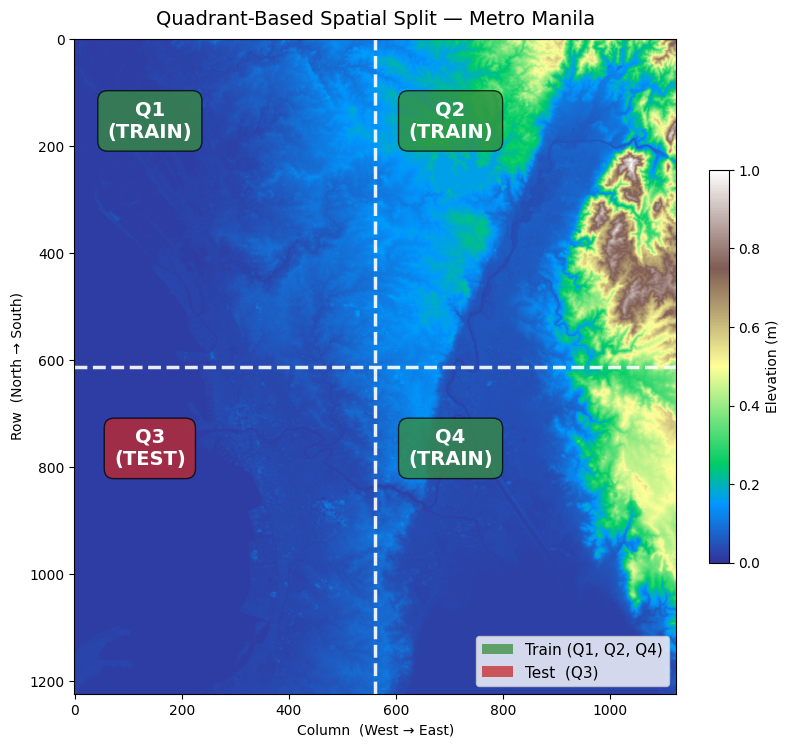

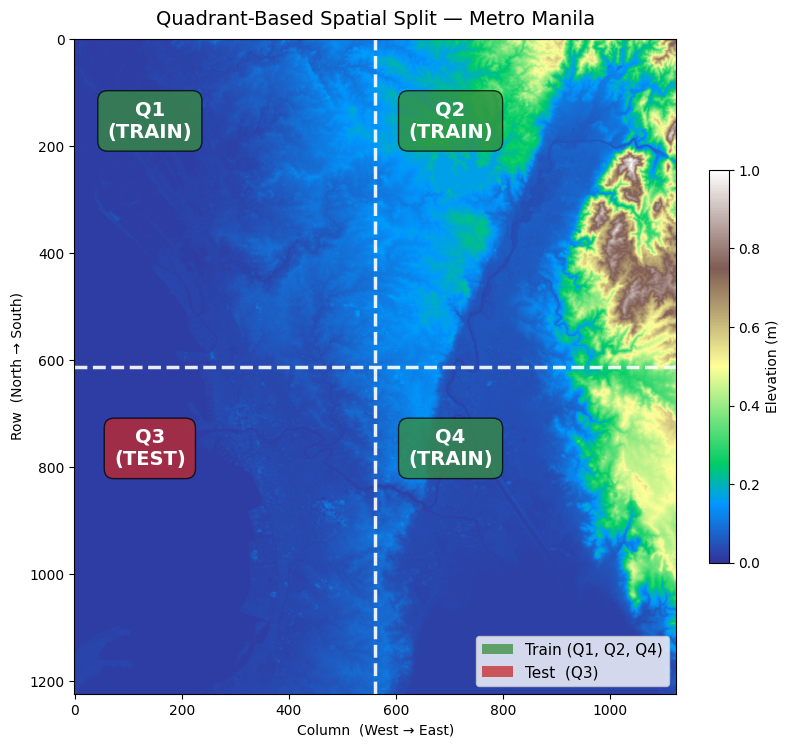

In [19]:
visualize_quadrant_split(dem_normalized)

# Rainfall Encoding

In [20]:
all_intensities = np.concatenate([df['intensity_mmhr'].values for df in rainfall_scenarios])
rain_min, rain_max = all_intensities.min(), all_intensities.max()

def normalize_rainfall_scenarios(rainfall_scenarios, rain_min, rain_max):
    normalized = []
    for df in rainfall_scenarios:
        intensity = (df['intensity_mmhr'].values - rain_min) / (rain_max - rain_min)
        normalized.append(intensity.astype(np.float32))
    return np.stack(normalized, axis=0) 

rain_embeddings = normalize_rainfall_scenarios(rainfall_scenarios, rain_min, rain_max)
print(rain_embeddings.shape) 

(50, 13)


# Manila Box

In [ ]:
import numpy as np
from pathlib import Path
from config import TrainConfig

cfg_save = TrainConfig()
cfg_save.output_dir.mkdir(parents=True, exist_ok=True)

# ── Extract and save spatial patches ─────────────────────────────────────────
print(f" spatial_patches shape: {spatial_patches.shape}")  # (85986, 4, 4, 3)

# Spatial dimensions for exp-des-3 full domain
N_H, N_W = 306, 281
assert spatial_patches.shape[0] == N_H * N_W, (
    f"Expected {N_H*N_W} patches, got {spatial_patches.shape[0]}"
)

#  should be on Manila box only not the whole GMM, so perhaps we need to create again to spatial_patches only having Manila

save_path = cfg_save.output_dir / 'web_spatial_data.npz'
np.savez(
    save_path,
    spatial   = spatial_patches.astype(np.float32),   # (85986, 4, 4, 3)
    rain_min  = np.array([rain_min]),
    rain_max  = np.array([rain_max]),
    n_h       = np.array([N_H]),
    n_w       = np.array([N_W]),
)
print(f"\n  ✓ Saved → {save_path}")
print(f"    spatial  : {spatial_patches.shape}")
print(f"    rain_min : {rain_min}")
print(f"    rain_max : {rain_max}")
print(f"    n_h, n_w : {N_H}, {N_W}")

 spatial_patches shape: (85986, 4, 4, 3)

  ✓ Saved → checkpoints\web_spatial_data.npz
    spatial  : (85986, 4, 4, 3)
    rain_min : 0.0
    rain_max : 189.853086
    n_h, n_w : 306, 281


In [ ]:
# ── Build conditioning vectors (19-dim) ───────────────────────────────────────
# rain_embeddings shape: (50, 13) — already built
conditioning_vectors = build_all_conditioning_vectors(
    rain_embeddings   = rain_embeddings,      # (50, 13)
    scenario_metadata = scenario_metadata,
    depth_min         = depth_min,
    depth_max         = depth_max,
)   # → (50, 19)


Conditioning matrix shape: (50, 19)


In [ ]:
print("\nConditioning vector breakdown (dims):")
print("  [0 :13] = normalized rainfall sequence")
print("  [13:17] = storm type one-hot")
print("  [17]    = r  (tpeak fraction)")
print("  [18]    = normalized total depth")

for sid in [1, 11, 21, 31, 40]:
    v = conditioning_vectors[sid - 1]
    print(f"\n  RS{sid:>2} ({scenario_metadata[sid]['label']:<18})"
          f"  rain[:3]={v[:3].round(3)}"
          f"  onehot={v[13:17].astype(int)}"
          f"  r={v[17]:.2f}"
          f"  depth_norm={v[18]:.3f}")


Conditioning vector breakdown (dims):
  [0 :13] = normalized rainfall sequence
  [13:17] = storm type one-hot
  [17]    = r  (tpeak fraction)
  [18]    = normalized total depth

  RS 1 (SCS Front-loaded  )  rain[:3]=[0.209 0.436 0.487]  onehot=[1 0 0 0]  r=0.00  depth_norm=0.452

  RS11 (SCS Balanced      )  rain[:3]=[0.02  0.09  0.168]  onehot=[0 1 0 0]  r=0.00  depth_norm=0.411

  RS21 (SCS Back-loaded   )  rain[:3]=[0.    0.    0.003]  onehot=[0 0 1 0]  r=0.00  depth_norm=0.123

  RS31 (Triangular        )  rain[:3]=[0.016 0.031 0.047]  onehot=[0 0 0 1]  r=0.40  depth_norm=0.041

  RS40 (Triangular        )  rain[:3]=[0.039 0.078 0.117]  onehot=[0 0 0 1]  r=0.40  depth_norm=0.205


# ViT Config

In [ ]:
from config import Config
from model_config import model_factory, make_model
from training import FloodPatchDataset, train_kfold

cfg = Config()  
cfg.save(cfg.train.output_dir / 'config.json')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_dataset = FloodPatchDataset(
    X_spatial = dataset['X_train'],
    y_labels  = dataset['y_train'],
    rainfall  = conditioning_vectors,
)

[FloodPatchDataset]
  Spatial tokens : torch.Size([64566, 3, 4, 4])  (N_patches, C, H, W)
  Labels         : torch.Size([64566, 50])  (N_patches, N_scenarios)
  Rainfall       : torch.Size([50, 19])  (N_scenarios, timesteps)
  Total samples  : 3,228,300  (patches × scenarios)


# Training Setup

In [ ]:
# ── K-Fold Training ─────────────────────────────────────────────────────
fold_histories, best_fold = train_kfold(
    model_factory = model_factory(cfg.model),
    full_dataset  = train_dataset,
    y_train       = dataset['y_train'],
    cfg           = cfg.train,
    device        = device,
)


FOLD 1 / 2
  Train samples : 1,614,150
  Val   samples : 1,614,150
    [TRAIN] batch  1000/6306  loss=1.5321  acc=0.7224
    [TRAIN] batch  2000/6306  loss=1.5321  acc=0.7226
    [TRAIN] batch  3000/6306  loss=1.5321  acc=0.7229
    [TRAIN] batch  4000/6306  loss=1.5320  acc=0.7229
    [TRAIN] batch  5000/6306  loss=1.5320  acc=0.7232
    [TRAIN] batch  6000/6306  loss=1.5320  acc=0.7232
    [TRAIN] batch  6306/6306  loss=1.5320  acc=0.7232
    [VAL  ] batch  1000/6306  loss=1.5317  acc=0.7762
    [VAL  ] batch  2000/6306  loss=1.5316  acc=0.7764
    [VAL  ] batch  3000/6306  loss=1.5316  acc=0.7762
    [VAL  ] batch  4000/6306  loss=1.5316  acc=0.7764
    [VAL  ] batch  5000/6306  loss=1.5316  acc=0.7765
    [VAL  ] batch  6000/6306  loss=1.5316  acc=0.7764
    [VAL  ] batch  6306/6306  loss=1.5316  acc=0.7763
  Epoch  1/20  lr=0.000000  train_loss=1.5320  train_acc=0.7232  val_loss=1.5316  val_acc=0.7763  val_f1=0.1765
  → Best Macro F1: 0.1765
    [TRAIN] batch  1000/6306  loss=1.2

In [ ]:
# Loading best model
ckpt = torch.load(cfg.train.output_dir / f'fold_{best_fold+1}' / 'best_model.pt', map_location=device)
model = make_model(cfg.model)
model.load_state_dict(ckpt['model_state_dict'])
model.to(device).eval()

print(f"✓ Loaded fold {best_fold+1}")
print(f"  Best macro F1: {ckpt.get('best_macro_f1', 'N/A')}")

✓ Loaded fold 2
  Best macro F1: 0.4148740272777564


# Testing

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from testing import ( prepare_ground_truth, evaluate_all_scenarios, plot_metrics_summary, plot_per_scenario_metrics,plot_per_class_metrics, plot_flood_on_dem )

print("\nPreparing ground truth maps for test scenarios...")
ground_truth = prepare_ground_truth(
    y_test           = dataset['y_test'],     
    quadrant_indices = quadrant_indices,
    patch_metadata   = patch_metadata[0],
)


Preparing ground truth maps for test scenarios...

Preparing ground truth maps for test scenarios...
  Q3 patch grid : 153 rows × 140 cols = 21420 patches
  GT maps shape : (50, 153, 140)  ✓


In [ ]:
print("\nEvaluating all test scenarios...")
results = evaluate_all_scenarios(
    model           = model,
    X_test          = dataset['X_test'],
    y_test          = dataset['y_test'],
    conditioning_vectors = conditioning_vectors,
    ground_truth    = ground_truth,
    batch_size      = cfg.train.batch_size,
    device          = device,
    num_classes     = cfg.model.num_classes,
)


Evaluating all test scenarios...

Evaluating all test scenarios...
  RS01  Acc=0.5084  Prec=0.2596  Rec=0.2847  F1=0.2257  IoU=0.1571  Conf=0.578  Uncertain=65.4%
  RS02  Acc=0.4652  Prec=0.2139  Rec=0.2788  F1=0.1438  IoU=0.1017  Conf=0.676  Uncertain=52.8%
  RS03  Acc=0.5109  Prec=0.2595  Rec=0.2874  F1=0.2238  IoU=0.1567  Conf=0.570  Uncertain=63.8%
  RS04  Acc=0.4704  Prec=0.2622  Rec=0.2744  F1=0.2282  IoU=0.1525  Conf=0.569  Uncertain=19.3%
  RS05  Acc=0.4652  Prec=0.2398  Rec=0.2948  F1=0.1783  IoU=0.1260  Conf=0.599  Uncertain=53.3%
  RS06  Acc=0.5117  Prec=0.2612  Rec=0.2887  F1=0.2239  IoU=0.1570  Conf=0.568  Uncertain=63.4%
  RS07  Acc=0.4835  Prec=0.2447  Rec=0.2995  F1=0.1831  IoU=0.1244  Conf=0.638  Uncertain=52.9%
  RS08  Acc=0.4699  Prec=0.2677  Rec=0.3088  F1=0.2001  IoU=0.1414  Conf=0.580  Uncertain=55.5%
  RS09  Acc=0.4751  Prec=0.2808  Rec=0.2764  F1=0.2462  IoU=0.1650  Conf=0.534  Uncertain=25.6%
  RS10  Acc=0.5075  Prec=0.2654  Rec=0.2854  F1=0.2298  IoU=0.1587  


Generating visualizations...


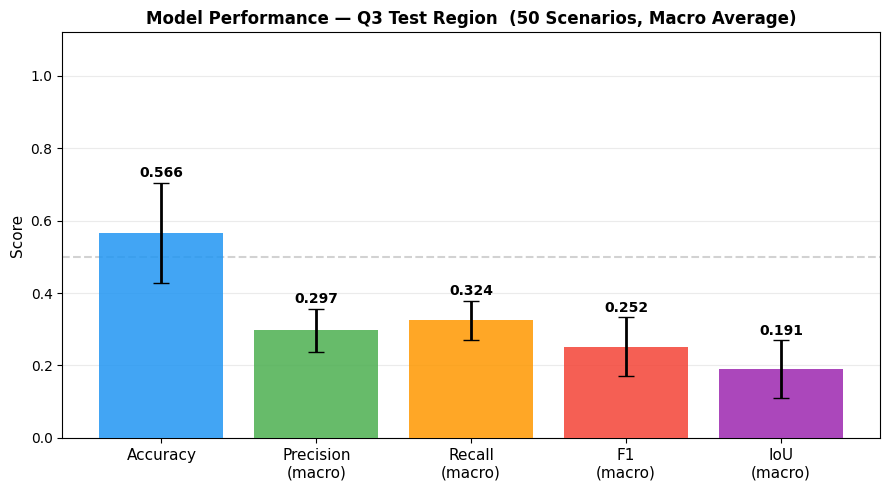

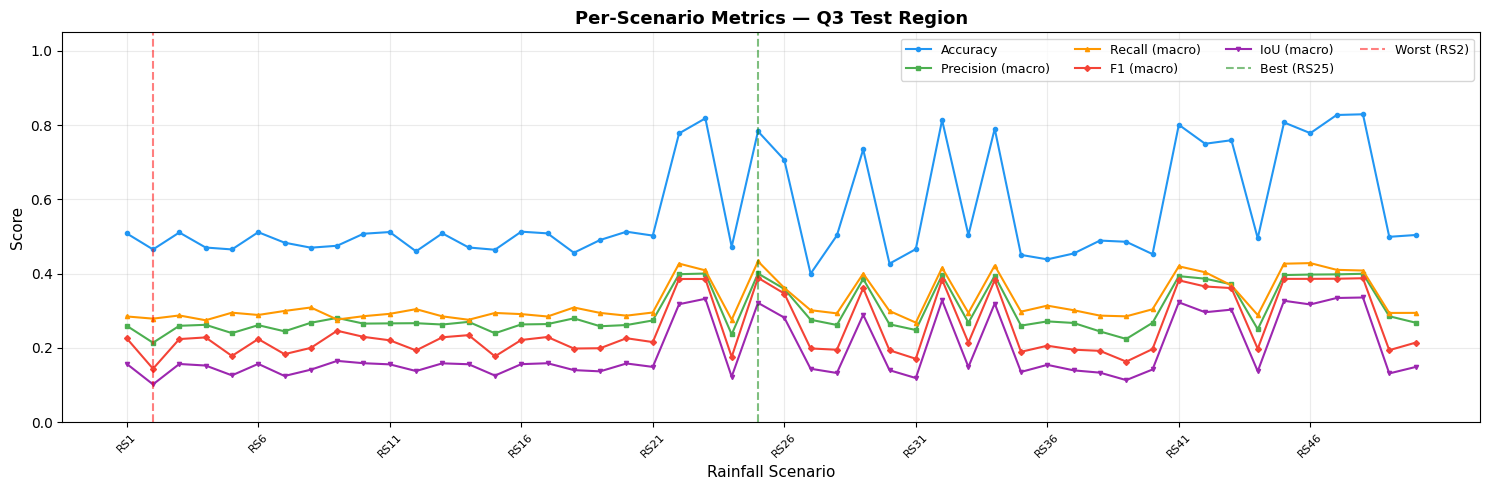

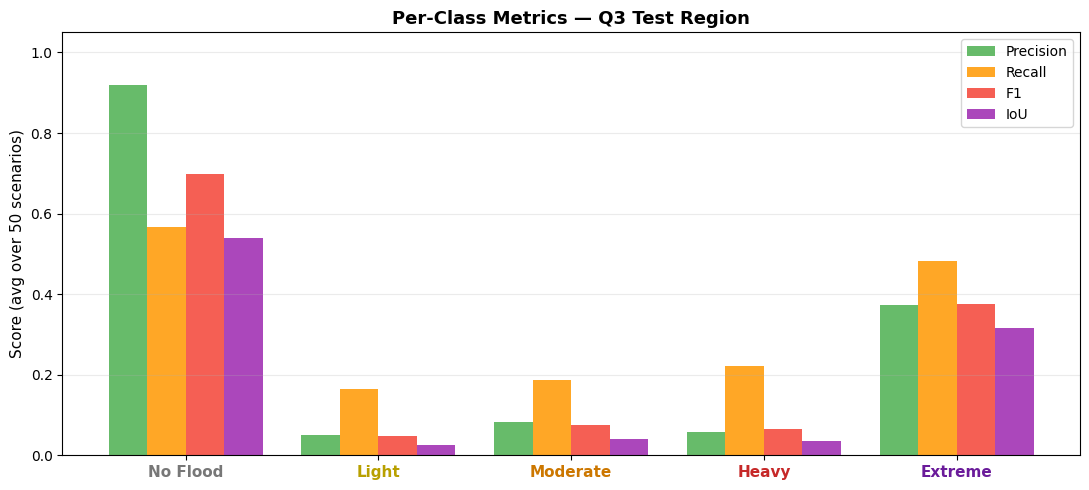

In [ ]:
print("\nGenerating visualizations...")

fig1 = plot_metrics_summary(results)
fig1.savefig("eval_metrics_summary.png", dpi=150, bbox_inches='tight')

fig2 = plot_per_scenario_metrics(results)
fig2.savefig("eval_per_scenario.png", dpi=150, bbox_inches='tight')

fig3 = plot_per_class_metrics(results)
fig3.savefig("eval_per_class.png", dpi=150, bbox_inches='tight')

plt.show()

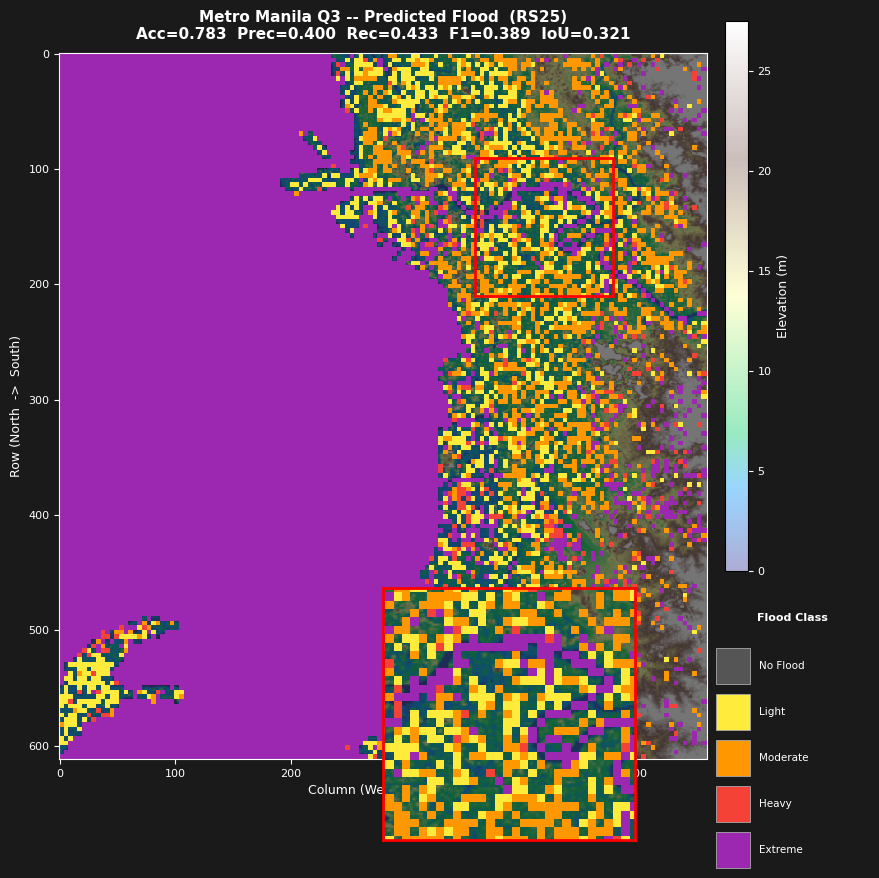

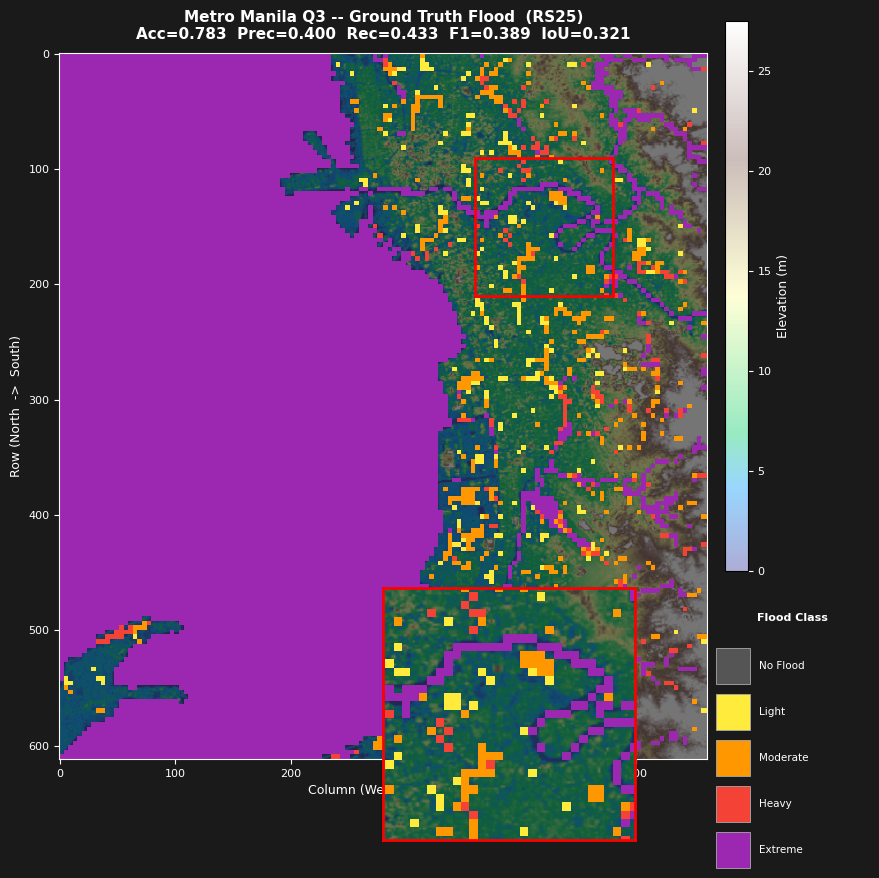


All figures saved.
  Best  scenario: RS25
  Worst scenario: RS2


In [ ]:
H_dem, W_dem = dem_clean.shape
dem_q3 = dem_clean[H_dem//2:, :W_dem//2]   

best_idx  = results['aggregate']['best_scenario']  - 1
worst_idx = results['aggregate']['worst_scenario'] - 1

# Single scenario — predicted
fig4 = plot_flood_on_dem(
    dem_q3      = dem_q3,
    flood_map   = results['pred_maps'][best_idx],
    scenario_id = results['aggregate']['best_scenario'],
    metrics     = results['per_scenario'][best_idx],
    mode        = 'pred',
    inset_center= (150, 420),
    figsize     = (9, 11),
    inset_size  = 60
)
fig4.savefig("eval_dem_best_pred.png", dpi=150, bbox_inches='tight')

# Single scenario — ground truth
fig5 = plot_flood_on_dem(
    dem_q3      = dem_q3,
    flood_map   = results['gt_maps'][best_idx],
    scenario_id = results['aggregate']['best_scenario'],
    metrics     = results['per_scenario'][best_idx],
    mode        = 'gt',
    inset_center=(150, 420),
    figsize     = (9, 11),
    inset_size  = 60
)
fig5.savefig("eval_dem_best_gt.png", dpi=150, bbox_inches='tight')

plt.show()
print("\nAll figures saved.")
print(f"  Best  scenario: RS{results['aggregate']['best_scenario']}")
print(f"  Worst scenario: RS{results['aggregate']['worst_scenario']}")

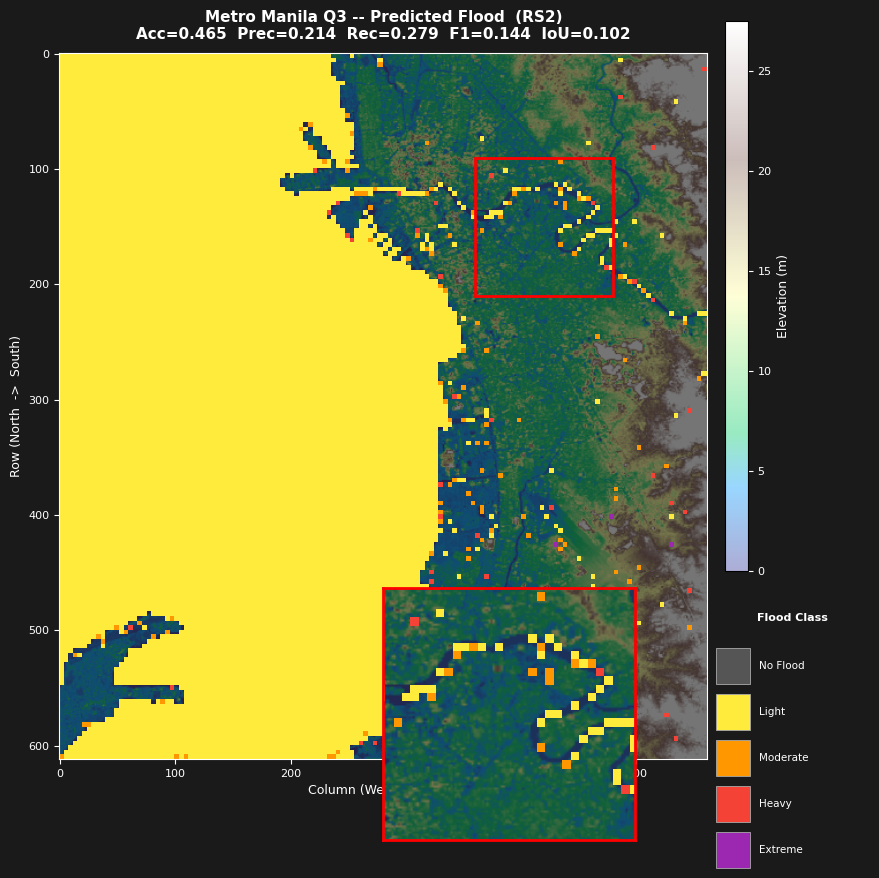

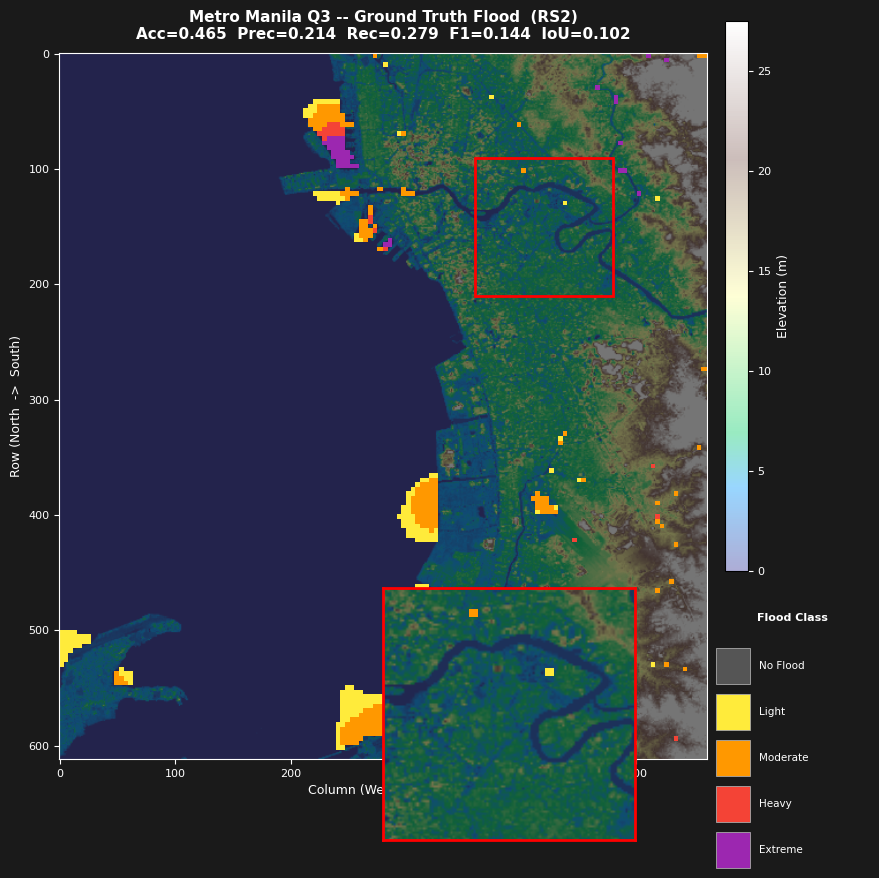

In [ ]:
fig6 = plot_flood_on_dem(
    dem_q3      = dem_q3,
    flood_map   = results['pred_maps'][worst_idx],
    scenario_id = results['aggregate']['worst_scenario'],
    metrics     = results['per_scenario'][worst_idx],
    mode        = 'pred',
    inset_center= (150, 420),
    figsize     = (9, 11),
    inset_size  = 60
)
fig6.savefig("eval_dem_worst_pred.png", dpi=150, bbox_inches='tight')

# Single scenario — ground truth
fig7 = plot_flood_on_dem(
    dem_q3      = dem_q3,
    flood_map   = results['gt_maps'][worst_idx],
    scenario_id = results['aggregate']['worst_scenario'],
    metrics     = results['per_scenario'][worst_idx],
    mode        = 'gt',
    inset_center=(150, 420),
    figsize     = (9, 11),
    inset_size  = 60
)
fig7.savefig("eval_dem_worst_gt.png", dpi=150, bbox_inches='tight')

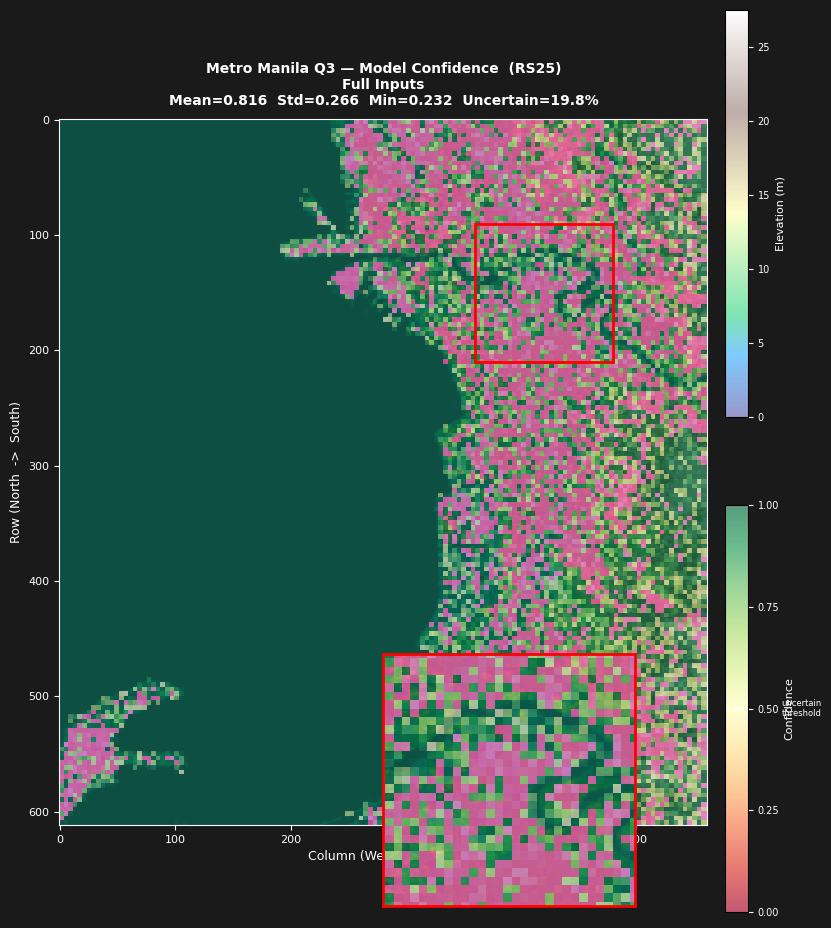

In [ ]:
from testing import plot_confidence_on_dem

best_idx  = results['aggregate']['best_scenario']  - 1

fig_conf = plot_confidence_on_dem(
    dem_q3       = dem_q3,
    conf_map     = results['conf_maps'][best_idx],
    scenario_id  = results['aggregate']['best_scenario'],
    config_label = 'Full Inputs',
    confs_flat   = results['per_scenario'][best_idx]['confs_flat'],
    inset_center = (150, 420),
    figsize      = (9, 11),
    inset_size   = 60,
)
fig_conf.savefig("eval_dem_best_confidence.png", dpi=150, bbox_inches='tight')
plt.show()